In [1]:
import numpy as np

import cma
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torchvision

from maps.dataset import Dataset
from maps.parameters import ParameterSpace
from maps.optim.optimizer import SceneOptimizer
from maps.optim.evaluator import NeuronEvaluator, SpatialNeuronObjective

In [2]:
object_name = 'white-shark_001'
root = '/Users/sgalella/Documents/datasets/MAPS/scenes'
path_labels = '/Users/sgalella/Documents/datasets/MAPS/labels.csv'

sigma = 0.2
seed = 1234
max_iter = 20
stop_prob = 0.9

In [3]:
dataset = Dataset(root=root)
print(dataset)

Dataset
  root:    /Users/sgalella/Documents/datasets/MAPS/scenes
  classes: 60
  scenes:  100


Read blend: "/Users/sgalella/Documents/datasets/MAPS/scenes/white-shark/white-shark_001.blend"
Cycles set to GPU via METAL


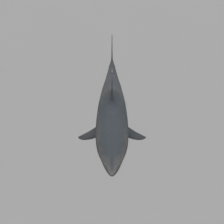

In [4]:
scene = dataset.get_scene(object_name)
scene.render()

In [5]:
parameters_scene = scene.get()
print(parameters_scene)

{'background.hue': 0.0, 'background.noise': 0.0, 'background.saturation': 0.0, 'background.value': 1.0, 'camera.azimuth': 0.0, 'camera.distance': 5.0, 'camera.elevation': 0.7853981852531433, 'camera.fstop': 10.0, 'camera.roll': 0.0, 'floor.alpha': 0.0, 'floor.hue': 0.0, 'floor.noise': 0.0, 'floor.saturation': 0.0, 'floor.value': 0.800000011920929, 'light.azimuth': 0.0, 'light.elevation': 0.0, 'light.hue': 0.0, 'light.power': 1.0, 'light.radius': 0.0, 'light.saturation': 0.0}


In [6]:
dict_space = {
    'background.hue': {'range': [0, 2 * np.pi]},
    'background.noise': {'range': [0, 1]},
    'background.saturation': {'range': [0, 1]},
    'background.value': {'range': [0, 1]},
    'camera.azimuth': {'range': [0, 2 * np.pi]},
    'camera.distance': {'range': [2, 8]},
    'camera.elevation': {'range': [0, np.pi]},
}

parameter_space = ParameterSpace(dict_space)
print(parameter_space)

ParameterSpace
  Total dimension: 7
  Parameters:
    - background.hue: [0, 6.283185307179586]
    - background.noise: [0, 1]
    - background.saturation: [0, 1]
    - background.value: [0, 1]
    - camera.azimuth: [0, 6.283185307179586]
    - camera.distance: [2, 8]
    - camera.elevation: [0, 3.141592653589793]


In [7]:
if torch.cuda.is_available():
        print(f'Using GPU: {torch.cuda.get_device_name(0)}')
        device = torch.device('cuda')
elif torch.backends.mps.is_available():
    print('Using Apple Silicon GPU')
    device = torch.device('mps')
else:
    print('Using CPU')
    device = torch.device('cpu')

Using Apple Silicon GPU


In [8]:
df_labels = pd.read_csv(path_labels)

class_name = object_name.split('_')[0]
class_id = df_labels[df_labels['name'] == class_name]['label'].item()
print(f'{class_name} label: {class_id}')

white-shark label: 2


In [9]:
weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V1
preprocess = weights.transforms()

model = torchvision.models.resnet50(weights=weights)
model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [10]:
def num_neurons_in_layer(layer):
    if isinstance(layer, nn.Conv2d):
        return layer.out_channels
    elif isinstance(layer, nn.Linear):
        return layer.out_features 
    else:
        raise ValueError(f"Unsupported layer type: {type(layer)}")

In [11]:
layer = model.layer4[2].conv3
idx = 200
i = 2
j = 2

num_neurons_layer = num_neurons_in_layer(layer)
print(f'Number of neurons in layer: {num_neurons_layer}')
assert idx < num_neurons_layer
objective = SpatialNeuronObjective(idx, i, j)

Number of neurons in layer: 2048


In [12]:
neuron_evaluator = NeuronEvaluator(model, preprocess, layer, idx, objective, class_id, device)
scene_optimizer = SceneOptimizer(scene, parameter_space, neuron_evaluator)

In [13]:
np.random.seed(seed)

initial_parameters = parameter_space.sample()
initial_x = parameter_space.encode(initial_parameters)
bounds = parameter_space.bounds()

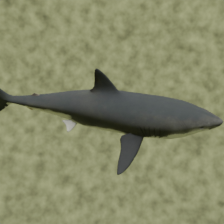

In [14]:
scene.set(initial_parameters)
scene.render()

In [15]:
opts = {'bounds': bounds, 'seed': seed}

cma_es = cma.CMAEvolutionStrategy(initial_x, sigma, opts)

(4_w,9)-aCMA-ES (mu_w=2.8,w_1=49%) in dimension 7 (seed=1234, Sun Jan 11 20:34:44 2026)


In [16]:
best, history = scene_optimizer.run(cma_es, max_iter=max_iter)

[ 1/20] Best score:  -0.009 | Best prob: 0.013 (405) | Iter. mean score:  -0.055 | Time/iter.: 6.87s
[ 2/20] Best score:   0.008 | Best prob: 0.036 (3) | Iter. mean score:  -0.026 | Time/iter.: 6.54s
[ 3/20] Best score:   0.023 | Best prob: 0.024 (405) | Iter. mean score:  -0.033 | Time/iter.: 6.40s
[ 4/20] Best score:   0.038 | Best prob: 0.003 (405) | Iter. mean score:  -0.029 | Time/iter.: 6.50s
[ 5/20] Best score:   0.038 | Best prob: 0.003 (405) | Iter. mean score:  -0.046 | Time/iter.: 6.33s
[ 6/20] Best score:   0.038 | Best prob: 0.003 (405) | Iter. mean score:  -0.041 | Time/iter.: 6.43s
[ 7/20] Best score:   0.038 | Best prob: 0.003 (405) | Iter. mean score:  -0.013 | Time/iter.: 6.25s
[ 8/20] Best score:   0.044 | Best prob: 0.045 (4) | Iter. mean score:  -0.003 | Time/iter.: 6.55s
[ 9/20] Best score:   0.044 | Best prob: 0.045 (4) | Iter. mean score:   0.012 | Time/iter.: 6.95s
[10/20] Best score:   0.049 | Best prob: 0.008 (405) | Iter. mean score:   0.009 | Time/iter.: 6.

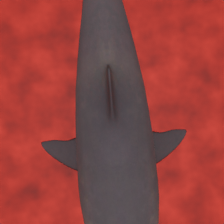

In [17]:
best_params = parameter_space.decode(best['x'])
scene.set(best_params)
scene.render()

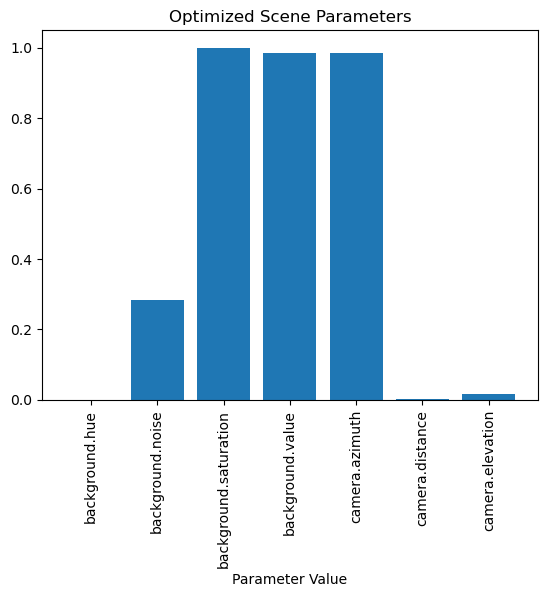

In [18]:
# Normalized parameter values [0, 1]
param_names = parameter_space.param_names
plt.bar(param_names, best['x'])
plt.xticks(rotation=90)
plt.xlabel('Parameter Value')
plt.title('Optimized Scene Parameters')
plt.show()